<a href="https://colab.research.google.com/github/SalvatoreSisay/Challenge-Telecome-X-part2/blob/main/Telecom_X_parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom X parte 2

##  🤖 Predicción de Cancelación de Clientes

la nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.
La empresa quiere anticiparse al problema de la cancelación, a partir de los datos previamente tratados y analizados en la Parte 1 del desafío, construiremos un pipeline de preprocesamiento y modelado para identificar probabilidades.

### Importación y limpieza inicial de los datos

In [1]:
#se realizara una limpieza final orientada al modelado predictivo, eliminando variables irrelevantes y definiendo la variable objetivo.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv('/content/telecom_datos_tratado.csv')

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_bin,PaperlessBilling_bin
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,0,1
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0,0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1,1
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1,1
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1,1


In [5]:
#Hago una copia de la BD para poder manipularlo con seguridad de no romper el original
df_copy_ml = df.copy()

# Elimino columnas que no se usaran
df_copy_ml.drop(columns=["customerID", "Churn"], inplace=True)

df_copy_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer.gender            7043 non-null   object 
 1   customer.SeniorCitizen     7043 non-null   int64  
 2   customer.Partner           7043 non-null   object 
 3   customer.Dependents        7043 non-null   object 
 4   customer.tenure            7043 non-null   int64  
 5   phone.PhoneService         7043 non-null   object 
 6   phone.MultipleLines        7043 non-null   object 
 7   internet.InternetService   7043 non-null   object 
 8   internet.OnlineSecurity    7043 non-null   object 
 9   internet.OnlineBackup      7043 non-null   object 
 10  internet.DeviceProtection  7043 non-null   object 
 11  internet.TechSupport       7043 non-null   object 
 12  internet.StreamingTV       7043 non-null   object 
 13  internet.StreamingMovies   7043 non-null   objec

In [6]:
df_copy_ml["Churn_bin"].value_counts(normalize=True)

,proportion
Churn_bin,
0,0.73463
1,0.26537


## 🎯 Correlación y Selección de Variables

### Análisis de correlación

In [7]:
numeric_cols = df_copy_ml.select_dtypes(include=["int64", "float64"]).columns
numeric_cols

Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly',
       'account.Charges.Total', 'Cuentas_Diarias', 'Churn_bin',
       'PaperlessBilling_bin'],
      dtype='object')

In [9]:
corr_matrix = df_copy_ml[numeric_cols].corr()
corr_matrix

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_bin,PaperlessBilling_bin
customer.SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.220173,0.150889,0.156530
customer.tenure,0.016567,1.000000,0.247900,0.826178,0.247900,-0.352229,0.006152
account.Charges.Monthly,0.220173,0.247900,1.000000,0.651174,1.000000,0.193356,0.352150
account.Charges.Total,0.103006,0.826178,0.651174,1.000000,0.651174,-0.198324,0.158574
Cuentas_Diarias,0.220173,0.247900,1.000000,0.651174,1.000000,0.193356,0.352150
Churn_bin,0.150889,-0.352229,0.193356,-0.198324,0.193356,1.000000,0.191825
PaperlessBilling_bin,0.156530,0.006152,0.352150,0.158574,0.352150,0.191825,1.000000


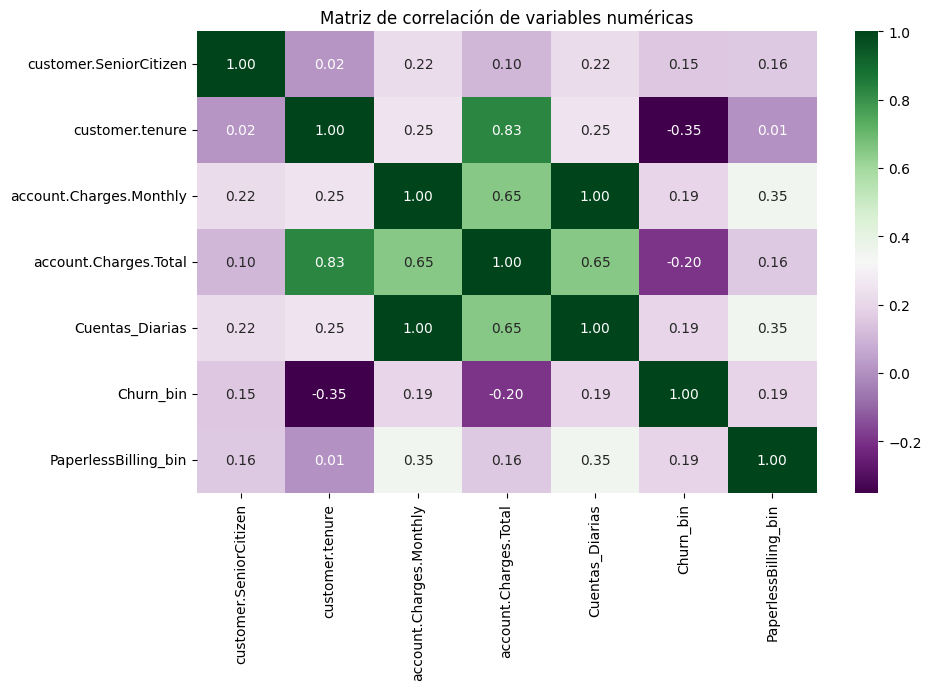

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="PRGn",
    fmt=".2f"
)
plt.title("Matriz de correlación de variables numéricas")
plt.show()

**Lo que dice el grafico:**
* customer.tenure (antigüedad del cliente): Presenta la correlación negativa más fuerte con Churn_bin (-0.35). Esto sugiere que cuanto más tiempo ha sido cliente una persona, es menos probable que abandone el servicio.
* account.Charges.Monthly (cargos mensuales) y Cuentas_Diarias: Ambas variables muestran una correlación positiva débil con Churn_bin (0.19 y 0.19 respectivamente). Esto indica que los clientes con cargos mensuales más altos tienen una ligera tendencia a ser más propensos a la cancelación.
* PaperlessBilling_bin (facturación sin papel): Tiene una correlación positiva débil con Churn_bin (0.19). Los clientes que optan por la facturación sin papel tienen una ligera mayor probabilidad de abandonar el servicio.
* customer.SeniorCitizen (cliente de tercera edad): Muestra una correlación positiva débil con Churn_bin (0.15). Los clientes de la tercera edad tienen una ligera mayor tendencia a cancelar.
* account.Charges.Total (cargos totales): Presenta una correlación negativa débil con Churn_bin (-0.19). A primera vista, podría parecer contradictorio con los cargos mensuales. Sin embargo, dado que account.Charges.Total es el producto de customer.tenure y account.Charges.Monthly, y la antigüedad tiene una fuerte correlación negativa, esto podría indicar que los clientes con una antigüedad muy larga acumulan cargos totales elevados pero son menos propensos a la cancelación.

### Análisis dirigido

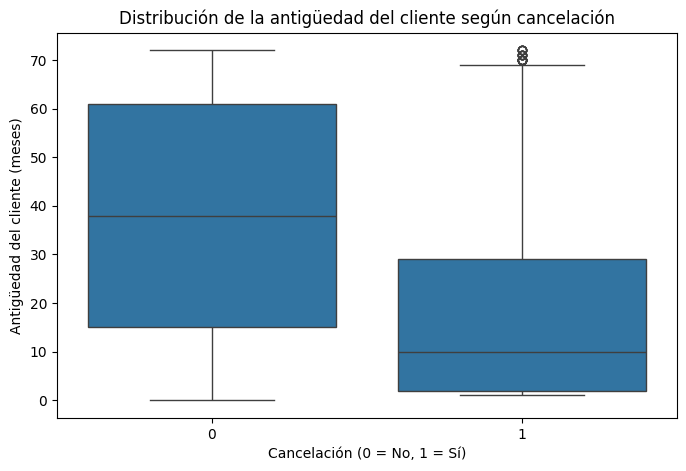

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Churn_bin",
    y="customer.tenure",
    data=df_copy_ml
)
plt.title("Distribución de la antigüedad del cliente según cancelación")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Antigüedad del cliente (meses)")
plt.show()

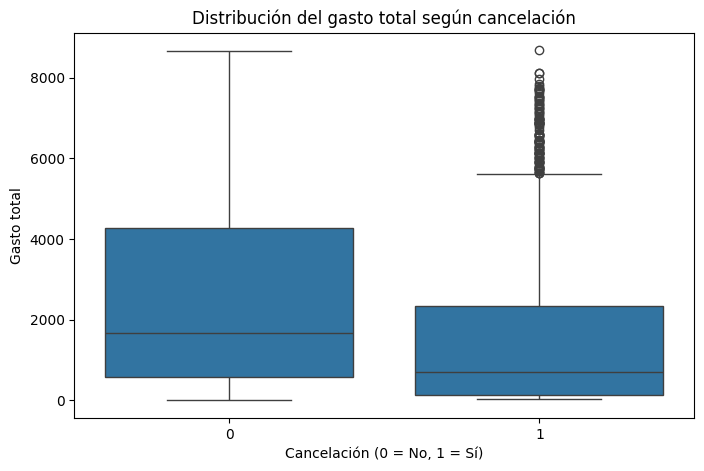

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Churn_bin",
    y="account.Charges.Total",
    data=df_copy_ml
)
plt.title("Distribución del gasto total según cancelación")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Gasto total")
plt.show()

se analisa las relaciones específicas entre variables clave y la cancelación de clientes para identificar patrones relevantes. Por lo tanto lo que vemos es Los clientes que cancelan el servicio presentan, en promedio, una antigüedad considerablemente menor que aquellos que permanecen activos y El gasto total acumulado de los clientes que cancelan es significativamente inferior, lo que refuerza la relación entre antigüedad y permanencia.

## 🤖 Modelado Predictivo

###Separación de Datos

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [17]:
# Variables predictivas y variable objetivo
X = df_copy_ml.drop(columns=["Churn_bin"])
y = df_copy_ml["Churn_bin"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

### Encoding

In [18]:
# Transformar columnas categóricas a numéricas
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

categorical_cols, numeric_cols

(Index(['customer.gender', 'customer.Partner', 'customer.Dependents',
        'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
        'internet.OnlineSecurity', 'internet.OnlineBackup',
        'internet.DeviceProtection', 'internet.TechSupport',
        'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
        'account.PaperlessBilling', 'account.PaymentMethod'],
       dtype='object'),
 Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly',
        'account.Charges.Total', 'Cuentas_Diarias', 'PaperlessBilling_bin'],
       dtype='object'))

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

In [20]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((4930, 42), (2113, 42))

In [21]:
("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_cols),
("num", "passthrough", numeric_cols)

('num',
 'passthrough',
 Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly',
        'account.Charges.Total', 'Cuentas_Diarias', 'PaperlessBilling_bin'],
       dtype='object'))

In [22]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((4930, 42), (2113, 42))

Se generó un conjunto de datos con 42 variables, combinando variables numéricas y categóricas transformadas mediante one-hot encoding.

### Creación de Modelos

In [23]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_processed, y_train)

y_pred_dummy = dummy.predict(X_test_processed)

#### **Modelo 1 — Árbol de Decisión**

In [24]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_processed, y_train)

y_pred_dt = dt.predict(X_test_processed)

#### **Modelo 2 — Regresión Logística con normalización**

In [25]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("scaler", MinMaxScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)

### Evaluación de los Modelos

In [26]:
def evaluar_modelo(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

In [29]:

resultados = {
    "Baseline (Dummy)": evaluar_modelo(y_test, y_pred_dummy),
    "Árbol de Decisión": evaluar_modelo(y_test, y_pred_dt),
    "Regresión Logística": evaluar_modelo(y_test, y_pred_logreg)
}

resultados_df = pd.DataFrame(resultados).T
resultados_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Accuracy,Precision,Recall,F1-score
Baseline (Dummy),0.734501,0.000000,0.000000,0.000000
Árbol de Decisión,0.728822,0.489899,0.518717,0.503896
Regresión Logística,0.796971,0.639831,0.538324,0.584705


**Conclusiones:** La Regresión Logística es el modelo que ofrece el mejor rendimiento para la predicción de cancelación de clientes entre los evaluados. Aunque el F1-score no es extremadamente alto, es una base sólida y significativamente mejor que las alternativas presentadas. Sugiere que este modelo puede ser útil para identificar a los clientes con mayor probabilidad de cancelar sus servicios y permitir a la empresa tomar acciones preventivas.

#### Matriz de confusión

In [32]:
# Matrices de confusión
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

cms = [cm_dummy, cm_dt, cm_logreg]
titulos = ["Baseline (Dummy)", "Árbol de Decisión", "Regresión Logística"]

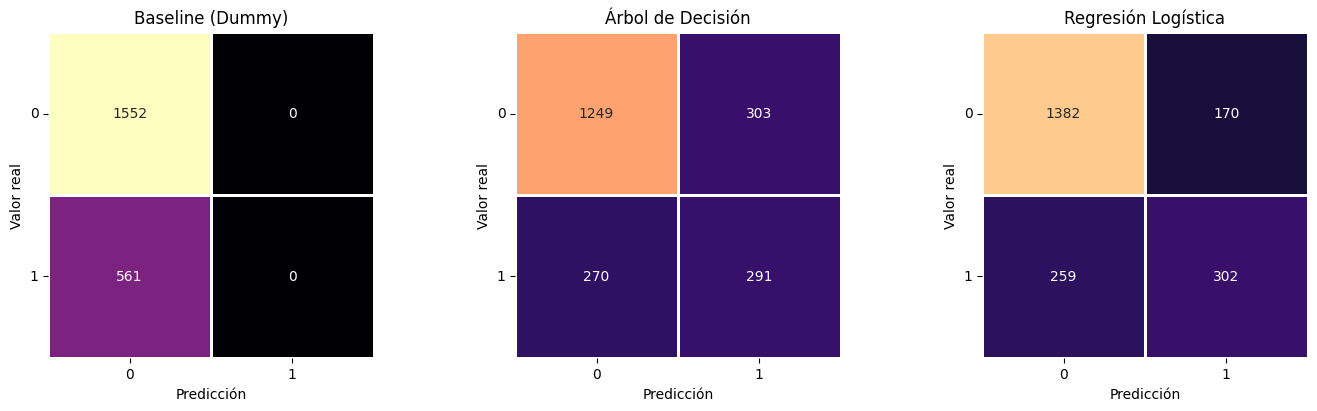

In [36]:
# Matrices (CONTEOS ABSOLUTOS) — escala común
vmax = max(cm.max() for cm in cms)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for ax, cm, titulo in zip(axes, cms, titulos):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="magma",
        vmin=0,
        vmax=vmax,
        cbar=False,
        square=True,
        linewidths=0.8,
        linecolor="white",
        ax=ax
    )
    ax.set_title(titulo)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"], rotation=0)

plt.show()

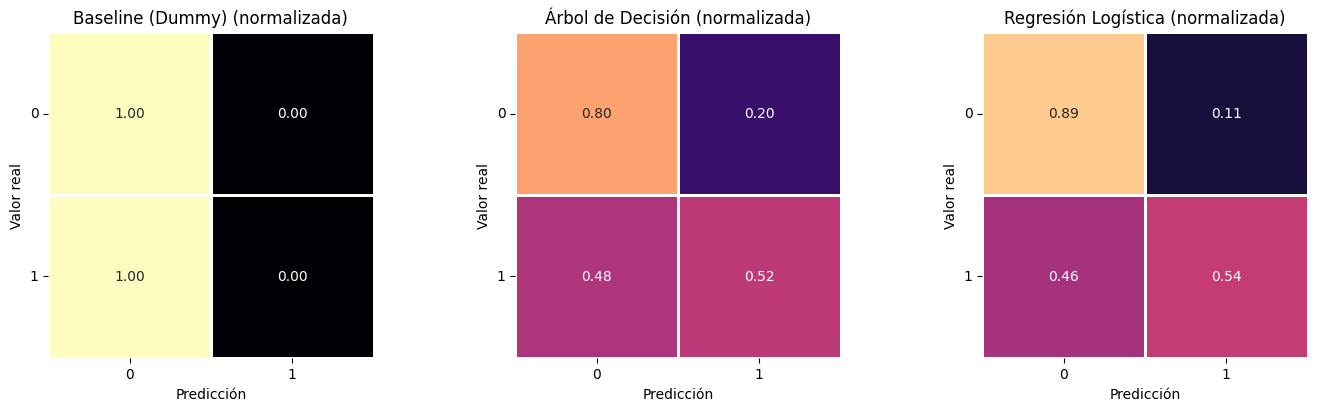

In [37]:
# Matrices por fila
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for ax, cm, titulo in zip(axes, cms, titulos):
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="magma",
        vmin=0,
        vmax=1,
        cbar=False,
        square=True,
        linewidths=0.8,
        linecolor="white",
        ax=ax
    )
    ax.set_title(f"{titulo} (normalizada)")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"], rotation=0)

plt.show()

## 📋 Interpretación y Conclusiones

### Análisis de la Importancia de las Variables

In [38]:
# Obtener los nombres de las variables luego del One-Hot Encoding
ohe = preprocessor.named_transformers_["cat"]
encoded_cat_cols = ohe.get_feature_names_out(categorical_cols)

# Unimos categóricas codificadas + numéricas
feature_names = np.concatenate([encoded_cat_cols, numeric_cols])

len(feature_names)

42

In [39]:
# Extraccion del coeficientes de la regresión logística
coeficientes = logreg_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coeficientes
})

coef_df.head()


,Variable,Coeficiente
0,customer.gender_Male,-0.086402
1,customer.Partner_Yes,-0.032902
2,customer.Dependents_Yes,-0.202550
3,phone.PhoneService_Yes,-0.220971
4,phone.MultipleLines_No,-0.246190


In [40]:
# Variables que aumentan la probabilidad de churn
top_positive = coef_df.sort_values("Coeficiente", ascending=False).head(10)
top_positive


,Variable,Coeficiente
39,account.Charges.Total,1.256297
28,account.Contract_Month-to-month,0.633932
8,internet.InternetService_Fiber optic,0.401710
34,account.PaymentMethod_Electronic check,0.245238
41,PaperlessBilling_bin,0.203393
31,account.PaperlessBilling_Yes,0.203393
19,internet.TechSupport_No,0.189754
36,customer.SeniorCitizen,0.166790
10,internet.OnlineSecurity_No,0.136302
24,internet.StreamingTV_Yes,0.108010


In [41]:
# Variables que reducen la probabilidad de cancelación
top_negative = coef_df.sort_values("Coeficiente").head(10)
top_negative

,Variable,Coeficiente
37,customer.tenure,-3.207906
30,account.Contract_Two year,-0.684750
7,internet.InternetService_DSL,-0.423110
4,phone.MultipleLines_No,-0.246190
3,phone.PhoneService_Yes,-0.220971
21,internet.TechSupport_Yes,-0.211154
2,customer.Dependents_Yes,-0.202550
33,account.PaymentMethod_Credit card (automatic),-0.199242
17,internet.DeviceProtection_No internet service,-0.157717
20,internet.TechSupport_No internet service,-0.157717


#### Representacion de las variables que influyen mas la cancelacion

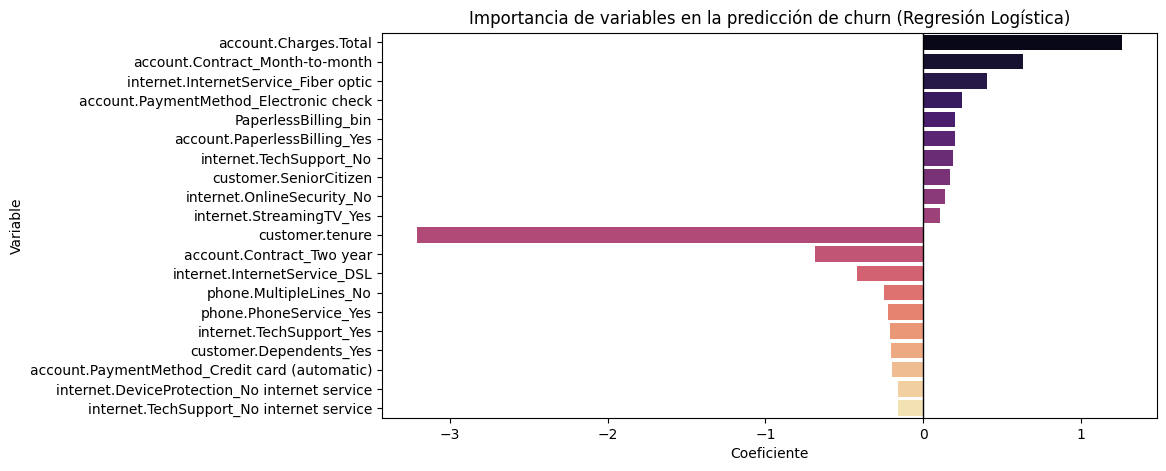

In [47]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=pd.concat([top_positive, top_negative]),
    x="Coeficiente",
    y="Variable",
    hue="Variable", # Added hue parameter
    palette="magma",
    legend=False # Added legend=False
)

plt.title("Importancia de variables en la predicción de churn (Regresión Logística)")
plt.axvline(0, color="black", linewidth=1)
plt.show()

## Predicción de Cancelación de Clientes (Churn)


### 1. Introducción y Objetivo

El objetivo principal de este proyecto fue desarrollar modelos predictivos capaces de identificar qué clientes de Telecom X tienen una mayor probabilidad de cancelar sus servicios (churn). A partir de los datos previamente tratados y analizados en la Parte 1 del desafío, construimos un pipeline de preprocesamiento y modelado para identificar estas probabilidades, permitiendo a la empresa anticiparse al problema y tomar acciones preventivas.

### 2. Preparación y Exploración de Datos

Después de una limpieza inicial, se eliminaron las columnas 'customerID' y 'Churn' originales, manteniendo 'Churn_bin' como nuestra variable objetivo (0 = No Cancela, 1 = Cancela). Se observó que el 26.54% de los clientes en nuestro dataset habían cancelado, lo que indica un problema de desequilibrio de clases, pero manejable.

El análisis de correlación y los boxplots revelaron patrones clave:

*   **Antigüedad del Cliente (`customer.tenure`):** La variable numérica con la correlación negativa más fuerte (-0.35) con la cancelación. Esto significa que los clientes con mayor antigüedad son significativamente menos propensos a cancelar. Los boxplots confirmaron que los clientes que cancelan tienen una antigüedad promedio mucho menor.
*   **Cargos Mensuales (`account.Charges.Monthly`) y Cargos Totales (`account.Charges.Total`):** `account.Charges.Monthly` mostró una correlación positiva débil con `Churn_bin` (0.19), mientras que `account.Charges.Total` presentó una correlación negativa débil (-0.19). Los boxplots mostraron que los clientes que cancelan tienen un gasto total acumulado significativamente menor, lo cual está alineado con su menor antigüedad.
*   **Facturación sin Papel (`PaperlessBilling_bin`):** Correlación positiva débil (0.19), sugiriendo que los clientes con facturación sin papel tienen una ligera mayor probabilidad de cancelar.
*   **Senior Citizen (`customer.SeniorCitizen`):** Correlación positiva débil (0.15), indicando una mayor propensión a cancelar en este segmento.

### 3. Modelado Predictivo y Evaluación

Se entrenaron y evaluaron tres modelos predictivos después de preprocesar los datos con OneHotEncoder para variables categóricas y preparar el conjunto de datos de entrenamiento y prueba:

1.  **Baseline (Dummy Classifier - 'most_frequent'):**
    *   Accuracy: 0.7345
    *   Precision, Recall, F1-score: 0.00
    *   Este modelo establece un umbral mínimo. Su alta precisión se debe a que predice consistentemente la clase mayoritaria (no churn), pero falla completamente en identificar a los clientes que sí cancelan.

2.  **Árbol de Decisión (`DecisionTreeClassifier`):**
    *   Accuracy: 0.7288
    *   Precision: 0.4899
    *   Recall: 0.5187
    *   F1-score: 0.5039
    *   Aunque logra predecir la cancelación, su rendimiento general es similar o incluso ligeramente inferior al baseline en términos de accuracy, y su F1-score indica un equilibrio mejor pero aún limitado en la identificación de churn.

3.  **Regresión Logística (`LogisticRegression` con normalización):**
    *   Accuracy: 0.7970
    *   Precision: 0.6398
    *   Recall: 0.5383
    *   F1-score: 0.5847
    *   Este modelo fue el claro ganador. Superó a los otros modelos en todas las métricas clave, ofreciendo el mejor equilibrio entre la identificación correcta de `churn` (Recall) y la minimización de falsos positivos (Precision), lo que se refleja en su `F1-score` más alto. La normalización de las características jugó un papel crucial en su rendimiento.

**Conclusión sobre Modelos:** La **Regresión Logística** es el modelo recomendado para la predicción de churn en este caso, debido a su superioridad en las métricas de evaluación, lo que la hace la herramienta más confiable para identificar a los clientes en riesgo.

### 4. Factores Clave que Influyen en la Cancelación (Basado en Regresión Logística)

El análisis de los coeficientes del modelo de Regresión Logística nos permite identificar los factores más influyentes:

**Variables que Aumentan Significativamente la Probabilidad de Cancelación (Factores de Riesgo):**

*   **`account.Contract_Month-to-month` (Contrato Mes a Mes):** Es el factor que más contribuye a la cancelación. La falta de un compromiso a largo plazo permite a los clientes cambiar fácilmente.
*   **`internet.InternetService_Fiber optic` (Servicio de Internet Fibra Óptica):** Clientes con fibra óptica tienen una mayor propensión a cancelar. Esto podría indicar problemas de calidad, precio o una alta competencia en este segmento.
*   **`account.Charges.Total` (Cargos Totales):** A mayor cargo total acumulado, mayor probabilidad de churn. Esto, combinado con una menor antigüedad, sugiere que clientes con servicios costosos que no han estado mucho tiempo pueden estar insatisfechos.
*   **`account.PaymentMethod_Electronic check` (Método de Pago Cheque Electrónico):** Este método de pago está asociado con un mayor riesgo de cancelación, quizás indicando un perfil de cliente menos estable o menos satisfecho con la experiencia de pago.
*   **`PaperlessBilling_bin` / `account.PaperlessBilling_Yes` (Facturación Sin Papel):** Los clientes que optan por esta modalidad tienen mayor probabilidad de cancelar. Podría ser un indicador de un perfil de cliente más digital y propenso a comparar servicios.
*   **`internet.TechSupport_No` (Sin Soporte Técnico en Internet):** La ausencia de soporte técnico es un claro impulsor de churn.
*   **`customer.SeniorCitizen` (Cliente de Tercera Edad):** Aunque un factor menor, los clientes de la tercera edad muestran una ligera mayor tendencia a cancelar.
*   **`internet.OnlineSecurity_No` (Sin Seguridad en Línea):** Similar al soporte técnico, la falta de seguridad online aumenta el riesgo.

**Variables que Reducen Significativamente la Probabilidad de Cancelación (Factores de Retención):**

*   **`customer.tenure` (Antigüedad del Cliente):** Es el factor más importante para la retención. Cada mes adicional como cliente reduce drásticamente la probabilidad de cancelación.
*   **`account.Contract_Two year` (Contrato de Dos Años):** Los contratos a largo plazo son un fuerte indicador de lealtad y reducen significativamente el churn.
*   **`internet.InternetService_DSL` (Servicio de Internet DSL):** Los clientes con DSL tienen una menor propensión a cancelar, sugiriendo una mayor satisfacción o menor exposición a la competencia en este segmento.
*   **`internet.TechSupport_Yes` (Con Soporte Técnico en Internet):** La presencia de soporte técnico es un factor protector contra la cancelación.
*   **`customer.Dependents_Yes` (Con Dependientes):** Los clientes con dependientes son menos propensos a cancelar, posiblemente porque tienen más necesidad de servicios estables o menos flexibilidad para cambiar.
*   **`account.PaymentMethod_Credit card (automatic)` (Tarjeta de Crédito Automática):** Este método de pago se asocia con una menor probabilidad de churn, indicando mayor comodidad o automatización que reduce la fricción.

### 5. Estrategias de Retención Basadas en los Resultados

Basándose en estos hallazgos, Telecom X puede implementar las siguientes estrategias para reducir la cancelación de clientes:

1.  **Fomentar Contratos a Largo Plazo:**
    *   **Acción:** Ofrecer incentivos atractivos (descuentos, beneficios adicionales, upgrades gratuitos) a clientes con contratos mes a mes para que migren a planes de 1 o 2 años.
    *   **Foco:** Especialmente en clientes nuevos o con baja antigüedad.

2.  **Programas de Lealtad y Compromiso Temprano:**
    *   **Acción:** Implementar programas de fidelización que recompensen la antigüedad y ofrezcan beneficios crecientes a medida que el cliente permanece más tiempo. Contactar proactivamente a clientes con baja antigüedad para asegurarse de su satisfacción.
    *   **Foco:** Clientes en sus primeros 6-12 meses de servicio.

3.  **Mejorar la Experiencia del Servicio de Fibra Óptica:**
    *   **Acción:** Realizar encuestas específicas a usuarios de fibra óptica. Investigar posibles fallas en el servicio, problemas de conectividad, competencia de precios o falta de valor percibido. Podría ser necesario mejorar la infraestructura, el soporte o las ofertas.
    *   **Foco:** Todos los clientes con servicio de fibra óptica.

4.  **Optimizar Métodos de Pago y Facturación:**
    *   **Acción:** Analizar la experiencia de los clientes que utilizan el cheque electrónico. Podría haber problemas con la usabilidad, la seguridad o la comodidad. Promover activamente la domiciliación bancaria o el pago automático con tarjeta de crédito como métodos de pago preferidos, destacando sus beneficios.
    *   **Foco:** Clientes con cheque electrónico y facturación sin papel.

5.  **Reforzar la Importancia del Soporte Técnico y la Seguridad en Línea:**
    *   **Acción:** Educar a los clientes sobre los beneficios del soporte técnico y la seguridad en línea. Ofrecer paquetes que incluyan estos servicios a precios competitivos o destacarlos como un valor añadido innegociable. Mejorar la calidad y accesibilidad del soporte técnico.
    *   **Foco:** Clientes sin soporte técnico y/o seguridad en línea, especialmente los de fibra óptica.

6.  **Atención Diferenciada a Clientes de Tercera Edad:**
    *   **Acción:** Considerar paquetes o soporte técnico especializado y de fácil acceso para este segmento. La simplicidad y la asistencia personalizada pueden ser clave.
    *   **Foco:** Clientes `SeniorCitizen`.

### 6. Conclusión

Este análisis ha proporcionado una comprensión clara de los factores más influyentes en la cancelación de clientes y ha identificado la Regresión Logística como el modelo más eficaz para predecir el churn. Al centrarse en mejorar la experiencia de los clientes con contratos mes a mes y servicios de fibra óptica, fomentar contratos a largo plazo, reforzar el soporte y la seguridad, y optimizar los métodos de pago, Telecom X puede desarrollar estrategias de retención más dirigidas y efectivas, transformando la predicción en acción y el riesgo en lealtad.